# MLB Home Run Distance Prediction Using Statcast Data

This project investigates the relationship between exit velocity, launch angle, and home run distance using MLB Statcast data.

The goal is to determine whether exit velocity and launch angle can be used to predict how far a home run travels.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pybaseball import statcast
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [2]:
data_month = statcast(
    start_dt="2024-04-01",
    end_dt="2024-04-30"
)

This is a large query, it may take a moment to complete


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:35<00:00,  1.19s/it]


In [3]:
home_runs_month = data_month[
    data_month["events"] == "home_run"
].copy()

## 1. Dataset

The dataset contains MLB Statcast data from April 2024.

- Total Statcast events: 116,768
- Home runs analyzed: 796
- Target variable: Home run distance (ft)
- Main features: Exit velocity (mph) and launch angle (degrees)

### Exploratory Data Analysis

First, we examine the relationships between the two input variables and home run distance.

Exit Velocity correlation: 0.6824900305774436


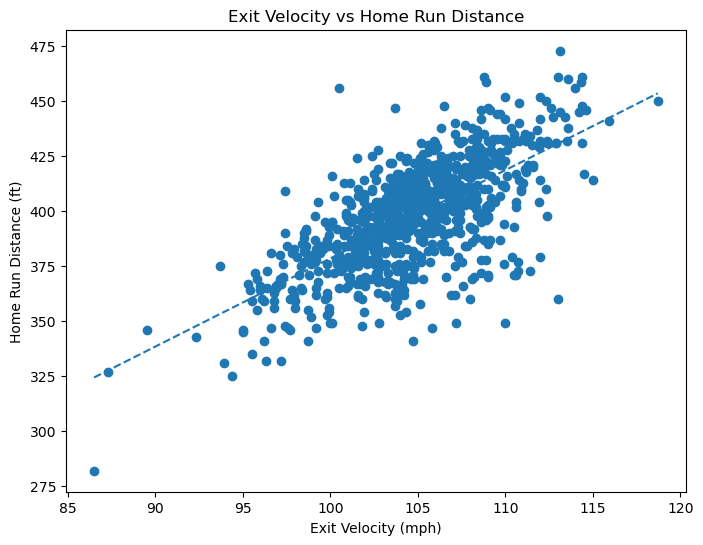

In [4]:
ev_corr = home_runs_month["launch_speed"].corr(
    home_runs_month["hit_distance_sc"]
)

print("Exit Velocity correlation:", ev_corr)

X_plot = home_runs_month["launch_speed"]
y_plot = home_runs_month["hit_distance_sc"]

model_plot = LinearRegression()
model_plot.fit(
    home_runs_month[["launch_speed"]],
    y_plot
)

y_line = model_plot.predict(
    home_runs_month[["launch_speed"]]
)

plt.figure(figsize=(8, 6))

plt.scatter(X_plot, y_plot)

sort_idx = X_plot.argsort()

plt.plot(
    X_plot.iloc[sort_idx],
    y_line[sort_idx],
    linestyle="--"
)

plt.xlabel("Exit Velocity (mph)")
plt.ylabel("Home Run Distance (ft)")
plt.title("Exit Velocity vs Home Run Distance")

plt.savefig("exit_velocity_vs_distance.png", dpi=300, bbox_inches="tight")

plt.show()

Exit velocity shows a positive relationship with home run distance. The correlation coefficient is approximately 0.682.

Launch Angle correlation: -0.18804306593924391


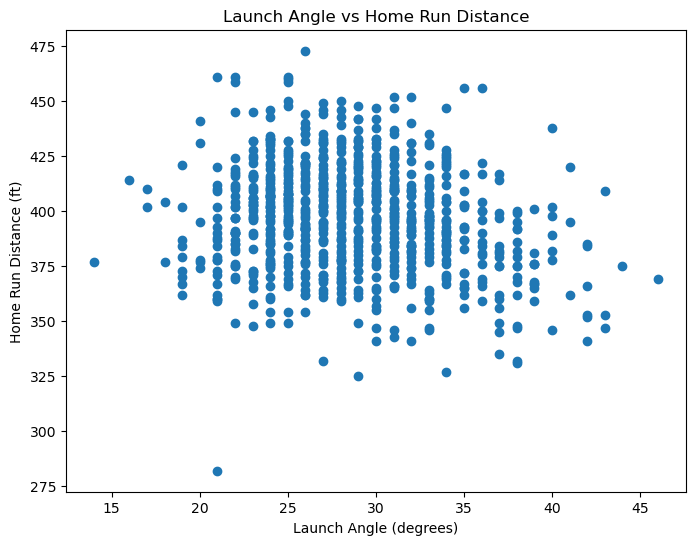

In [5]:
angle_corr = home_runs_month["launch_angle"].corr(
    home_runs_month["hit_distance_sc"]
)

print("Launch Angle correlation:", angle_corr)

plt.figure(figsize=(8, 6))

plt.scatter(
    home_runs_month["launch_angle"],
    home_runs_month["hit_distance_sc"]
)

plt.xlabel("Launch Angle (degrees)")
plt.ylabel("Home Run Distance (ft)")
plt.title("Launch Angle vs Home Run Distance")

plt.savefig("launch_angle_vs_distance.png", dpi=300, bbox_inches="tight")

plt.show()

Launch angle shows a much weaker linear relationship with home run distance, with a correlation coefficient of approximately -0.188.

## 2. Predictive Modeling

To evaluate whether these variables can predict home run distance, two linear regression models were developed and compared.

- **Model 1:** Exit velocity only
- **Model 2:** Exit velocity + launch angle

The data were divided into training and testing sets using an 80/20 split. Model performance was evaluated using R² and Mean Absolute Error (MAE).

### Model 1: Exit Velocity

The first model uses exit velocity as the only predictor of home run distance.

In [6]:
X_ev = home_runs_month[["launch_speed"]]
y_month = home_runs_month["hit_distance_sc"]

X_train_ev, X_test_ev, y_train_ev, y_test_ev = train_test_split(
    X_ev,
    y_month,
    test_size=0.2,
    random_state=42
)

model_ev = LinearRegression()
model_ev.fit(X_train_ev, y_train_ev)

y_pred_ev = model_ev.predict(X_test_ev)

r2_ev = model_ev.score(X_test_ev, y_test_ev)
mae_ev = mean_absolute_error(y_test_ev, y_pred_ev)

print("Model 1: Exit Velocity")
print("Testing R²:", r2_ev)
print("MAE:", mae_ev)

Model 1: Exit Velocity
Testing R²: 0.3663467954610532
MAE: 14.490599382748524


### Model 2: Exit Velocity + Launch Angle

The second model adds launch angle to examine whether it provides additional predictive information beyond exit velocity.

In [7]:
X_both = home_runs_month[["launch_speed", "launch_angle"]]

X_train_both, X_test_both, y_train_both, y_test_both = train_test_split(
    X_both,
    y_month,
    test_size=0.2,
    random_state=42
)

model_both = LinearRegression()
model_both.fit(X_train_both, y_train_both)

y_pred_both = model_both.predict(X_test_both)

r2_both = model_both.score(X_test_both, y_test_both)
mae_both = mean_absolute_error(y_test_both, y_pred_both)

print("Model 2: Exit Velocity + Launch Angle")
print("Testing R²:", r2_both)
print("MAE:", mae_both)

Model 2: Exit Velocity + Launch Angle
Testing R²: 0.36868976267361886
MAE: 14.487741800873627


## 3. Model Evaluation

The models are evaluated using the testing data to measure their performance on unseen observations.

- **R²:** Measures the proportion of variance in home run distance explained by the model.
- **MAE:** Measures the average absolute prediction error in feet. Lower values indicate better performance.

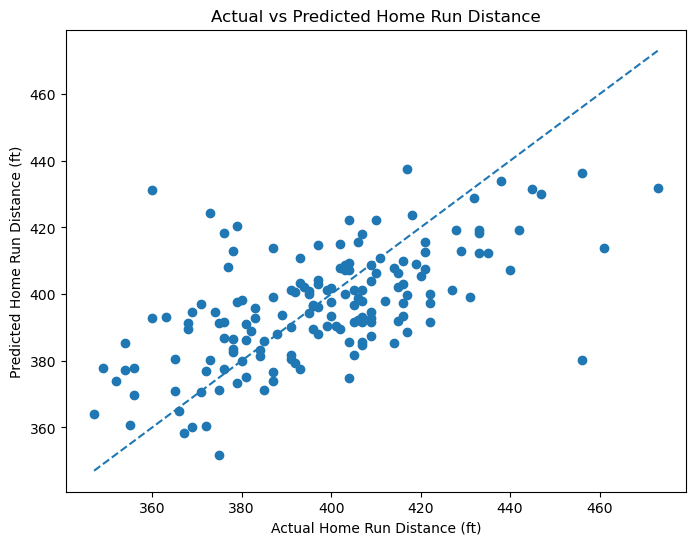

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_both, y_pred_both)

plt.plot(
    [y_test_both.min(), y_test_both.max()],
    [y_test_both.min(), y_test_both.max()],
    linestyle="--"
)

plt.xlabel("Actual Home Run Distance (ft)")
plt.ylabel("Predicted Home Run Distance (ft)")
plt.title("Actual vs Predicted Home Run Distance")

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

### Model Comparison

The two models are compared based on their test-set R² and MAE.

In [9]:
results = {
    "Model": [
        "Exit Velocity",
        "Exit Velocity + Launch Angle"
    ],
    "Test R²": [
        r2_ev,
        r2_both
    ],
    "MAE (ft)": [
        mae_ev,
        mae_both
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Test R²,MAE (ft)
0,Exit Velocity,0.366347,14.490599
1,Exit Velocity + Launch Angle,0.368690,14.487742


## 4. Conclusion

Exit velocity showed a stronger linear relationship with home run distance (r = 0.682) than launch angle (r = -0.188).

The model using exit velocity alone achieved a test R² of 0.366 and an MAE of 14.49 ft. Adding launch angle resulted in only a marginal improvement, increasing the test R² to 0.369 while leaving the MAE almost unchanged at 14.49 ft.

These results suggest that exit velocity provides more useful linear predictive information for home run distance than launch angle in this dataset. However, the moderate R² indicates that other factors also contribute substantially to home run distance.

Overall, this project demonstrates how MLB Statcast data can be used for exploratory analysis, predictive modeling, and model comparison in a baseball analytics context.